# Momepy roads - Berlin

This notebook uses momepy to calculate geometrical and topological features of the Berlin street network:
- **Street profile**: `width`, `openness`, `width_deviation` (requires OSM buildings)
- **Betweenness centrality** (node-based, local radius 500 m, propagated to edges via mean_nodes)
- **Closeness centrality** -- extended local (radius 800 m) and local 400 m
- **Straightness centrality** (node-based, radius 500 m)

Input: `BER_noise_streets.gpkg` -- the Berlin OSM drive streets with acoustic zone noise classes.

Local-radius variants are used for tractability, matching the Berlin pipeline.

## Import libraries

In [11]:
import os
import momepy as mm
import geopandas as gpd
import osmnx as ox
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

## Import streets segments

In [12]:
_layers_dir = os.path.join(os.path.dirname(os.path.abspath(os.getcwd())), 'layers')
edges = gpd.read_file(os.path.join(_layers_dir, 'BER_noise_streets.gpkg'))
print(edges.crs)
print(edges.shape)
print(edges.columns.tolist())
print('Number of street segments:', len(edges))

EPSG:25833
(70890, 12)
['segment_id', 'highway', 'name', 'length', 'GES_DEN_mean', 'GES_N_mean', 'noise_day', 'noise_evening', 'noise_night', 'n_points', 'distance', 'geometry']
Number of street segments: 70890


In [13]:
place_name = 'Berlin, Germany'
tags = {'building': True}

print('Downloading buildings from OSM...')
try:
    buildings = ox.features_from_place(place_name, tags)
except AttributeError:
    buildings = ox.geometries_from_place(place_name, tags)

print(f'Downloaded {len(buildings)} buildings.')
buildings = buildings[buildings.geometry.type.isin(['Polygon', 'MultiPolygon'])]
buildings = buildings.to_crs(edges.crs)
print(f'Polygon buildings: {len(buildings)}')

Downloaded 503022 buildings.
Polygon buildings: 502965


## Create Momepy street profile

In [14]:
profile = mm.street_profile(edges, buildings)
profile.head()

,width,openness,width_deviation
0,28.940821,0.728070,3.174008
1,43.648847,0.924419,1.857882
2,37.132640,0.797297,2.742866
3,50.000000,1.000000,NaN
4,49.244843,0.933333,0.615090


In [15]:
edges[profile.columns] = profile
edges[profile.columns].head()

,width,openness,width_deviation
0,28.940821,0.728070,3.174008
1,43.648847,0.924419,1.857882
2,37.132640,0.797297,2.742866
3,50.000000,1.000000,NaN
4,49.244843,0.933333,0.615090


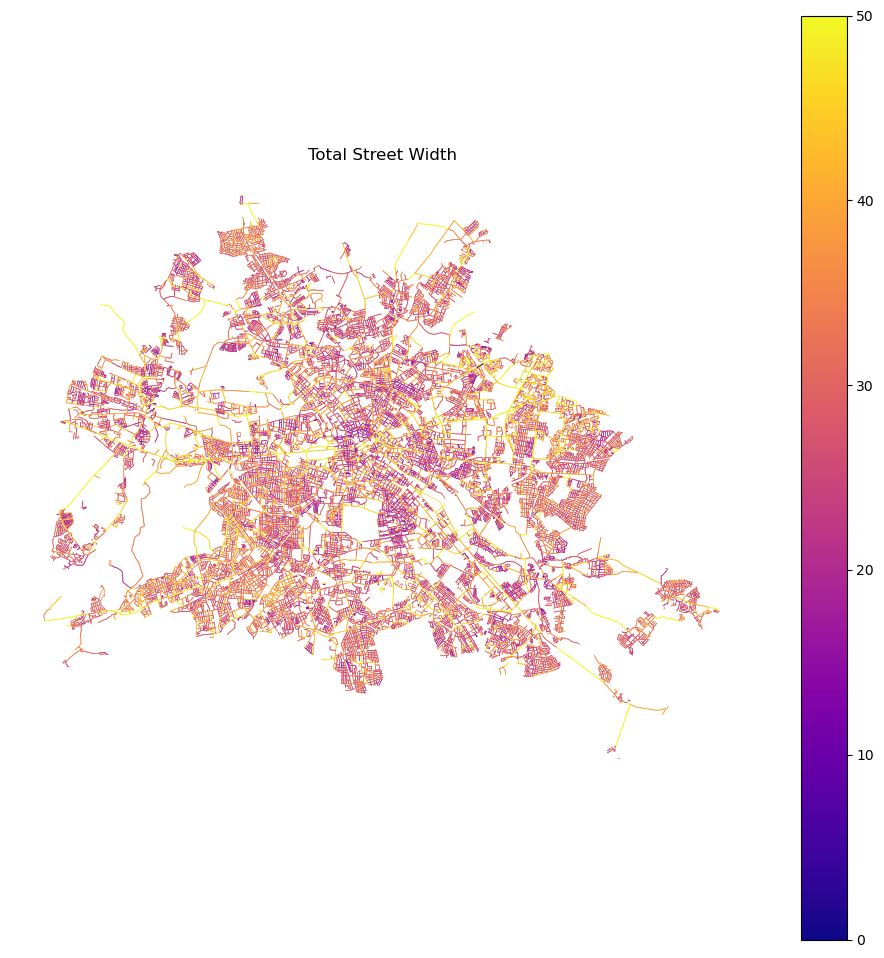

In [16]:
ax = edges.plot(cmap='plasma', column='width', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Total Street Width')
ax.set_axis_off()

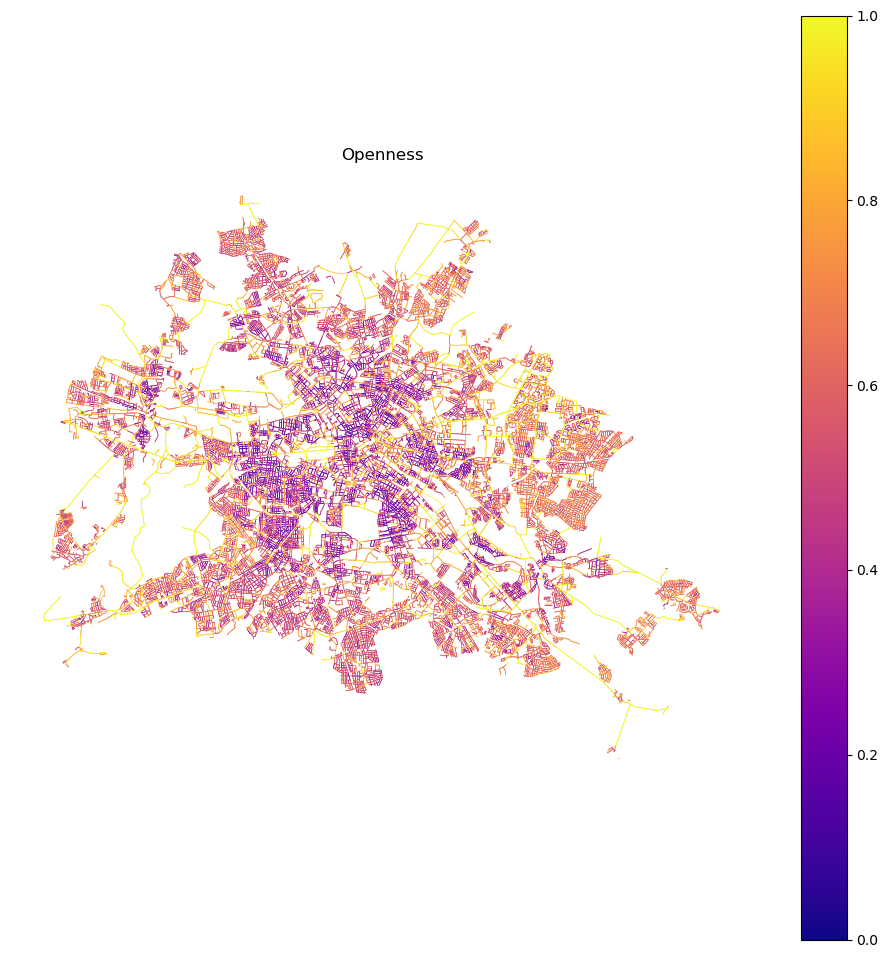

In [17]:
ax = edges.plot(cmap='plasma', column='openness', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Openness')
ax.set_axis_off()

# Centrality

Build the primal graph once; all centrality functions operate on it.

In momepy 0.11 all centralities are node-based. `mm.mean_nodes()` propagates each
node attribute to its incident edges (mean of the two endpoint values) before the
edge GeoDataFrame is extracted.

In [18]:
primal = mm.gdf_to_nx(edges, approach="primal")
print('Graph nodes:', primal.number_of_nodes(), '  edges:', primal.number_of_edges())

Graph nodes: 27898   edges: 70890


## Betweenness Centrality

In [19]:
betweenness = mm.betweenness_centrality(
    primal, name='betweenness_metric_e', mode='edges', weight='mm_len',
)

In [20]:
primal_gdf_betw = mm.nx_to_gdf(betweenness, points=False)
primal_gdf_betw.head()

,segment_id,highway,name,length,GES_DEN_mean,GES_N_mean,noise_day,noise_evening,noise_night,n_points,distance,geometry,width,openness,width_deviation,mm_len,betweenness_metric_e
0,172539_172562_0,secondary,Gotthardstraße,436.954554,53.849999,46.000000,2,2,1,4,0.0,"LINESTRING (387179.738 5825206.873, 387173.312...",28.940821,0.728070,3.174008,437.787811,0.004091
1,172562_172539_0,secondary,Gotthardstraße,436.954554,57.199999,49.320000,2,2,1,5,0.0,"LINESTRING (386844.252 5824925.718, 386848.467...",28.942026,0.728070,3.177924,437.787811,0.004091
2,172539_34694336_0,secondary,Gotthardstraße,687.372277,55.025000,47.531251,2,2,1,16,0.0,"LINESTRING (387179.738 5825206.873, 387187.035...",43.648847,0.924419,1.857882,689.267903,0.000911
3,34694336_172539_0,secondary,Gotthardstraße,687.372277,53.776923,46.284616,2,2,1,13,0.0,"LINESTRING (387838.067 5825368.55, 387811.94 5...",43.648664,0.924419,1.858070,689.267903,0.000911
4,172539_34694265_0,tertiary,Holländerstraße,240.982380,59.366667,49.953333,2,2,1,15,0.0,"LINESTRING (387179.738 5825206.873, 387184.593...",37.132640,0.797297,2.742866,241.575024,0.003291


Text(0.5, 1.0, 'Betweenness Centrality - Edge Mean (r=500 m)')

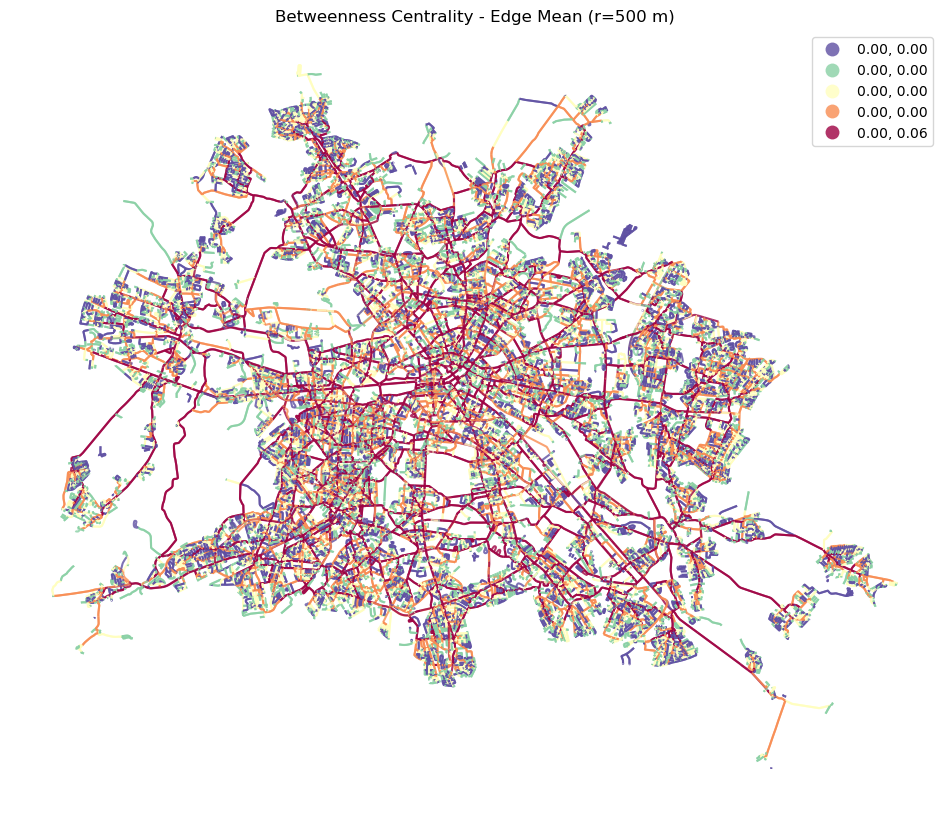

In [21]:
ax = primal_gdf_betw.plot(
    column='betweenness_metric_e',
    cmap='Spectral_r',
    scheme='quantiles',
    alpha=0.8,
    legend=True,
    figsize=(12, 12)
)
ax.set_axis_off()
ax.set_title('Betweenness Centrality - Edge Mean (r=500 m)')

## Global Closeness Centrality

Careful, takes a few minutes

In [22]:
closeness = mm.closeness_centrality(
    primal, name='closeness_global', weight='mm_len'
)

In [23]:
nodes = mm.nx_to_gdf(closeness, lines=False)
nodes.head()
nodes.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 27898 entries, 0 to 27897
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   x                 27898 non-null  float64 
 1   y                 27898 non-null  float64 
 2   closeness_global  27898 non-null  float64 
 3   nodeID            27898 non-null  int64   
 4   geometry          27898 non-null  geometry
dtypes: float64(3), geometry(1), int64(1)
memory usage: 1.1 MB


Text(0.5, 1.0, 'Closenness Global (Node Based)')

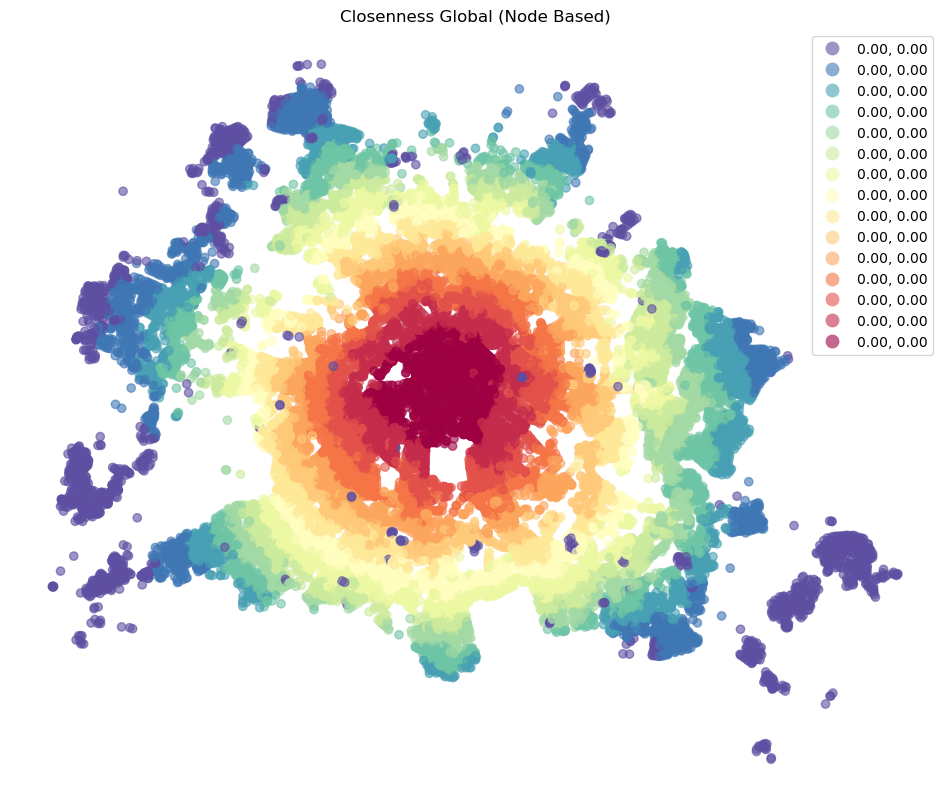

In [24]:
ax = nodes.plot(
    column="closeness_global",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(12, 12),
    legend=True
)
ax.set_axis_off()
ax.set_title("Closenness Global (Node Based)")

In [25]:
mm.mean_nodes(closeness, "closeness_global")

In [26]:
primal_gdf_clos = mm.nx_to_gdf(closeness, points=False)
primal_gdf_clos.head()

,segment_id,highway,name,length,GES_DEN_mean,GES_N_mean,noise_day,noise_evening,noise_night,n_points,distance,geometry,width,openness,width_deviation,mm_len,closeness_global
0,172539_172562_0,secondary,Gotthardstraße,436.954554,53.849999,46.000000,2,2,1,4,0.0,"LINESTRING (387179.738 5825206.873, 387173.312...",28.940821,0.728070,3.174008,437.787811,0.000069
1,172562_172539_0,secondary,Gotthardstraße,436.954554,57.199999,49.320000,2,2,1,5,0.0,"LINESTRING (386844.252 5824925.718, 386848.467...",28.942026,0.728070,3.177924,437.787811,0.000069
2,172539_34694336_0,secondary,Gotthardstraße,687.372277,55.025000,47.531251,2,2,1,16,0.0,"LINESTRING (387179.738 5825206.873, 387187.035...",43.648847,0.924419,1.857882,689.267903,0.000069
3,34694336_172539_0,secondary,Gotthardstraße,687.372277,53.776923,46.284616,2,2,1,13,0.0,"LINESTRING (387838.067 5825368.55, 387811.94 5...",43.648664,0.924419,1.858070,689.267903,0.000069
4,172539_34694265_0,tertiary,Holländerstraße,240.982380,59.366667,49.953333,2,2,1,15,0.0,"LINESTRING (387179.738 5825206.873, 387184.593...",37.132640,0.797297,2.742866,241.575024,0.000069


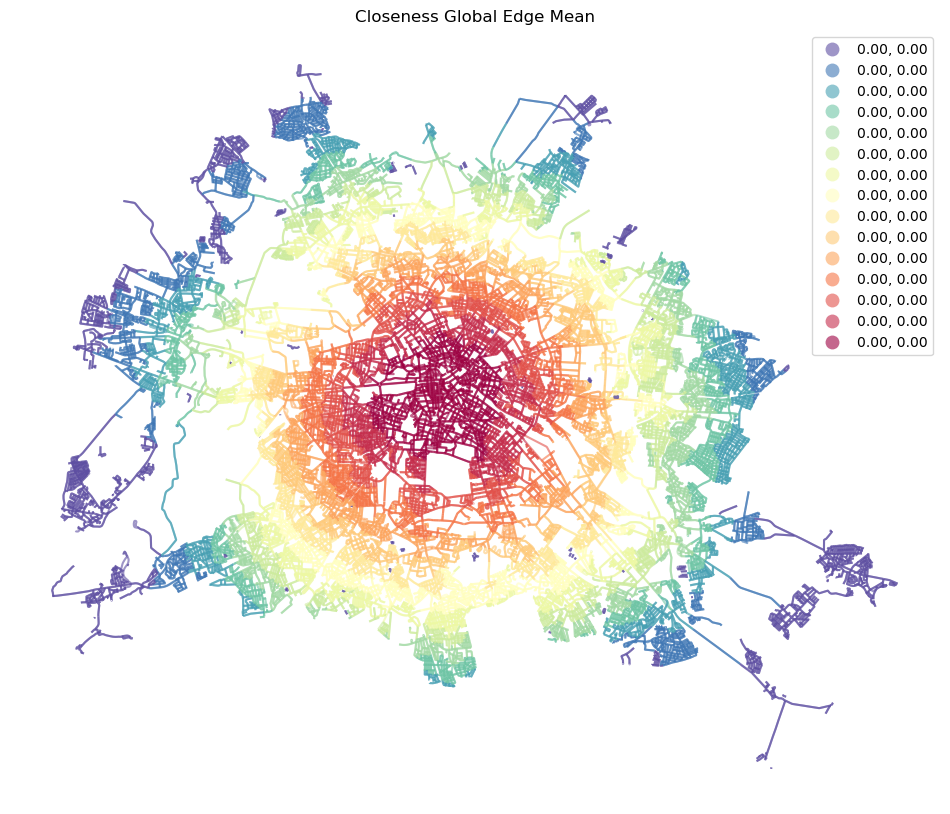

In [27]:

ax = primal_gdf_clos.plot(
    column="closeness_global",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(12, 12),
    legend=True
)
ax.set_axis_off()
_ = ax.set_title("Closeness Global Edge Mean")

## Local Closeness Centrality

In [28]:
local_clos = mm.closeness_centrality(
    primal, radius=400, name='closeness400', distance='mm_len', weight='mm_len'
)

  0%|          | 0/27898 [00:00<?, ?it/s]

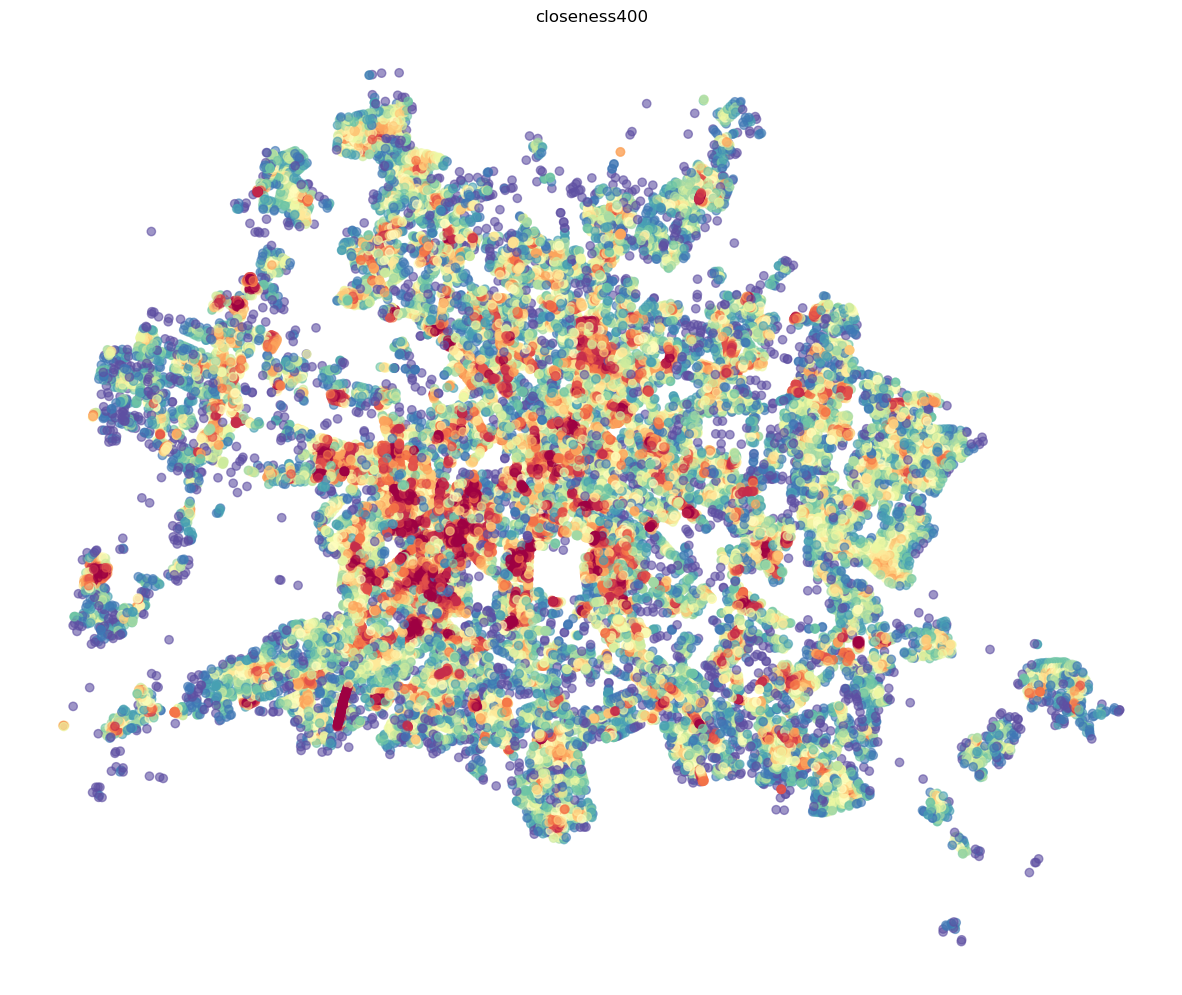

In [29]:
nodes = mm.nx_to_gdf(local_clos, lines=False)
ax = nodes.plot(
    column="closeness400",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(15, 15),
)
ax.set_axis_off()
_ = ax.set_title("closeness400")

In [30]:
mm.mean_nodes(local_clos, "closeness400")

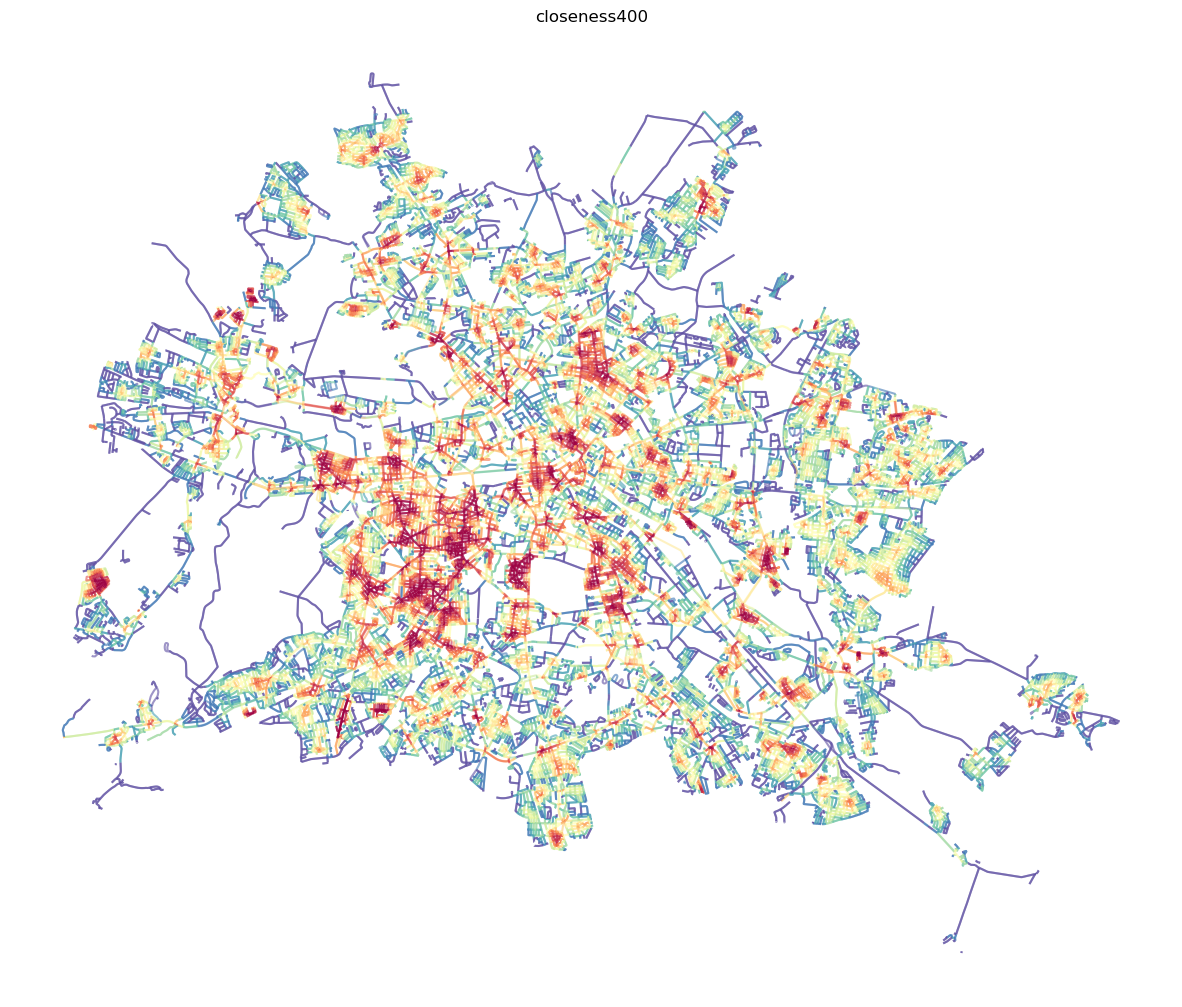

In [31]:
primal_gdf_clos400 = mm.nx_to_gdf(local_clos, points=False)

ax = primal_gdf_clos400.plot(
    column="closeness400",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(15, 15),
)
ax.set_axis_off()
_ = ax.set_title("closeness400")

## Straightness

In [32]:
straighteness = mm.straightness_centrality(
    primal
)

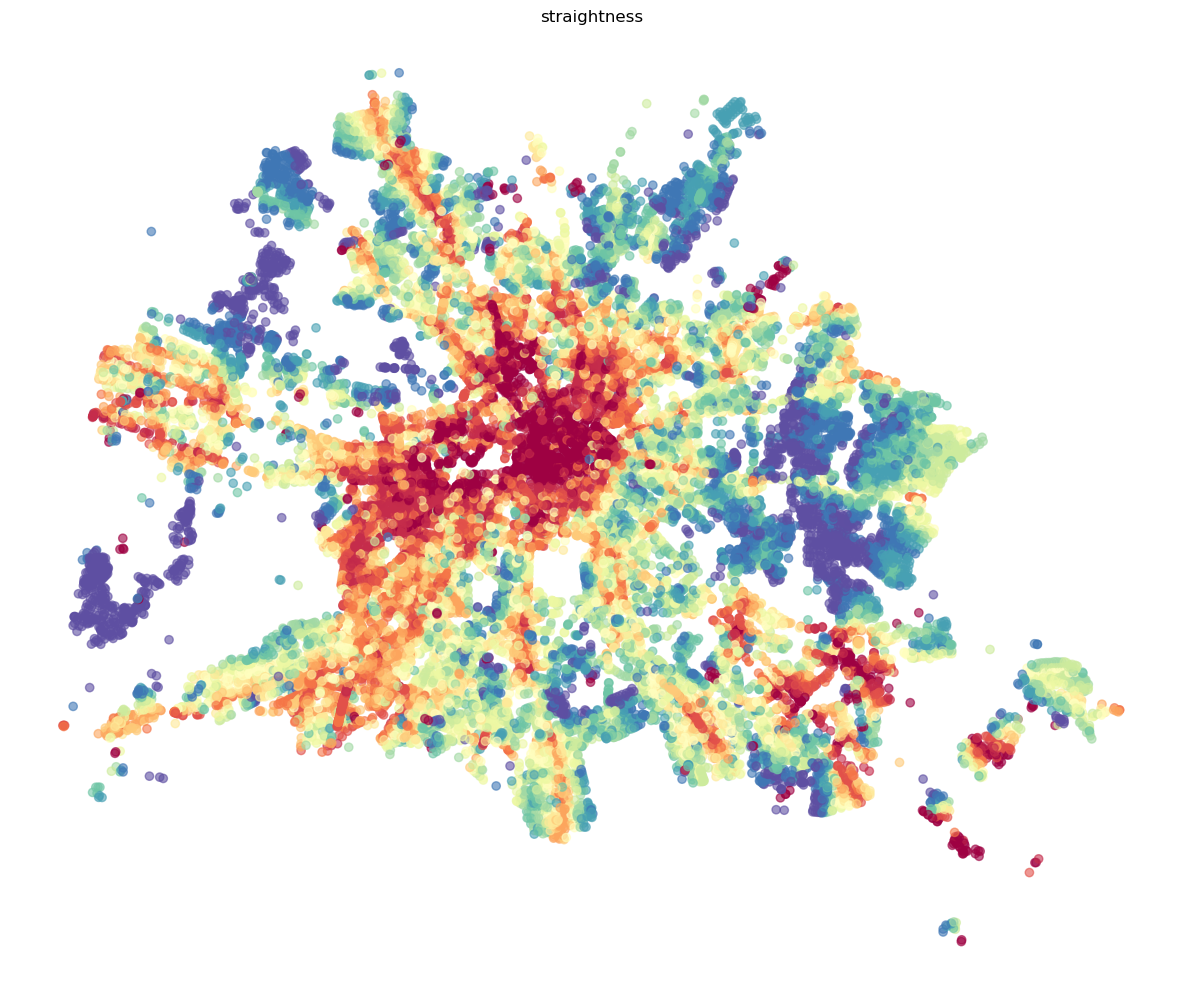

In [33]:
nodes = mm.nx_to_gdf(straighteness, lines=False)
ax = nodes.plot(
    column="straightness",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(15, 15),
)
ax.set_axis_off()
_ = ax.set_title("straightness")

In [34]:
mm.mean_nodes(straighteness, "straightness")

In [35]:
primal_gdf_str = mm.nx_to_gdf(straighteness, points=False)
primal_gdf_str.head()

,segment_id,highway,name,length,GES_DEN_mean,GES_N_mean,noise_day,noise_evening,noise_night,n_points,distance,geometry,width,openness,width_deviation,mm_len,straightness
0,172539_172562_0,secondary,Gotthardstraße,436.954554,53.849999,46.000000,2,2,1,4,0.0,"LINESTRING (387179.738 5825206.873, 387173.312...",28.940821,0.728070,3.174008,437.787811,0.852416
1,172562_172539_0,secondary,Gotthardstraße,436.954554,57.199999,49.320000,2,2,1,5,0.0,"LINESTRING (386844.252 5824925.718, 386848.467...",28.942026,0.728070,3.177924,437.787811,0.852416
2,172539_34694336_0,secondary,Gotthardstraße,687.372277,55.025000,47.531251,2,2,1,16,0.0,"LINESTRING (387179.738 5825206.873, 387187.035...",43.648847,0.924419,1.857882,689.267903,0.837846
3,34694336_172539_0,secondary,Gotthardstraße,687.372277,53.776923,46.284616,2,2,1,13,0.0,"LINESTRING (387838.067 5825368.55, 387811.94 5...",43.648664,0.924419,1.858070,689.267903,0.837846
4,172539_34694265_0,tertiary,Holländerstraße,240.982380,59.366667,49.953333,2,2,1,15,0.0,"LINESTRING (387179.738 5825206.873, 387184.593...",37.132640,0.797297,2.742866,241.575024,0.842749


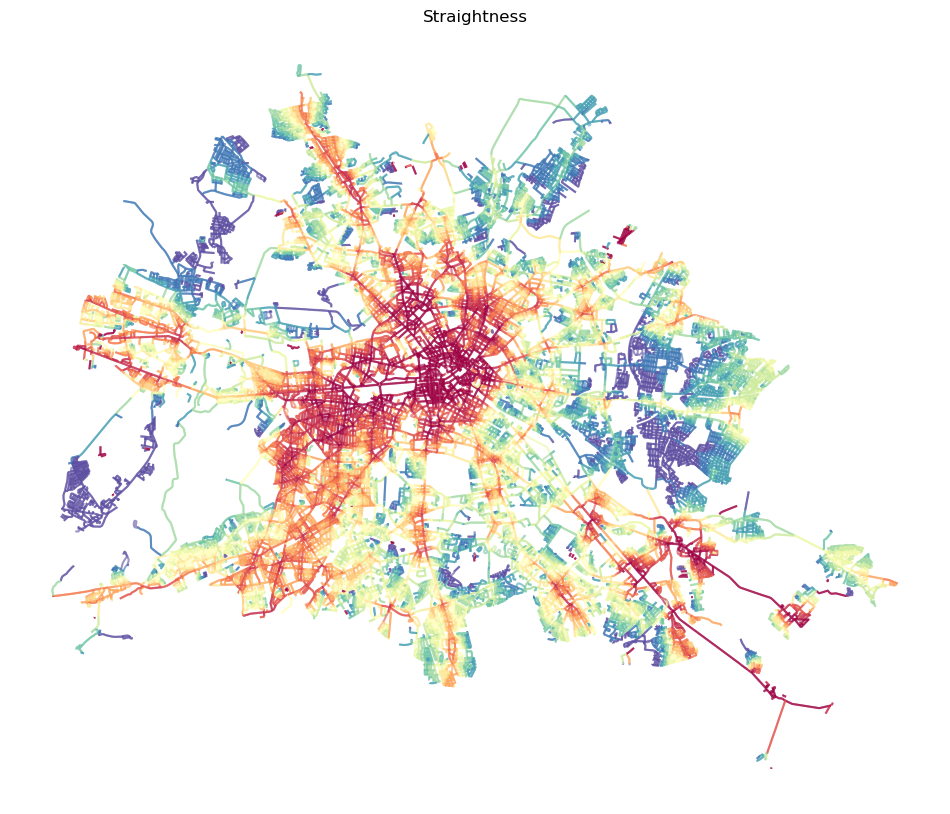

In [36]:
ax = primal_gdf_str.plot(
    column="straightness",
    cmap="Spectral_r",
    scheme="quantiles",
    k=15,
    alpha=0.6,
    figsize=(12, 12),
)
ax.set_axis_off()
_ = ax.set_title("Straightness")

## Create data frame

In [37]:
dataset = edges[['segment_id', 'width', 'openness']].copy()

dataset = (
    dataset
    .merge(primal_gdf_betw[['segment_id', 'betweenness_metric_e']], on='segment_id', how='left')
    .merge(primal_gdf_clos[['segment_id', 'closeness_global']], on='segment_id', how='left')
    .merge(primal_gdf_clos400[['segment_id', 'closeness400']], on='segment_id', how='left')
    .merge(primal_gdf_str[['segment_id', 'straightness']], on='segment_id', how='left')
    .rename(columns={
        'segment_id': 'road_id',
        'betweenness_metric_e': 'betweenness',
        'closeness400': 'closeness_400'
    })
    .fillna(0)
)

dataset.head()

,road_id,width,openness,betweenness,closeness_global,closeness_400,straightness
0,172539_172562_0,28.940821,0.728070,0.004091,0.000069,2.819245e-06,0.852416
1,172539_34694336_0,43.648847,0.924419,0.000911,0.000069,6.748056e-07,0.837846
2,172539_34694265_0,37.132640,0.797297,0.003291,0.000069,7.868624e-07,0.842749
3,172545_271370539_0,50.000000,1.000000,0.000005,0.000069,1.828302e-06,0.833956
4,172545_34694336_0,49.244843,0.933333,0.000774,0.000068,1.431952e-06,0.832365


## Export dataset to CSV

In [38]:
import os
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "momepy_roads_features.csv"), index=False)
print("Exported momepy_roads_features.csv")

Exported momepy_roads_features.csv
